In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

BATCH_SIZE   = 32
EPOCHS       = 200
LR           = 0.001
WEIGHT_DECAY = 1e-4
N_HEADS      = 5
FF_FACTOR    = 8
DROPOUT      = 0.4
TRAIN_N      = 240
VAL_N        = 60

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

dossier = '/content/drive/MyDrive/Data_P2'
print("\nFichiers disponibles :")
for f in sorted(os.listdir(dossier)):
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Fichiers disponibles :
  cov_climate_arkansas.npy
  cov_climate_california.npy
  cov_soil_arkansas.npy
  cov_soil_california.npy
  cov_topo_arkansas.npy
  cov_topo_california.npy
  labels_arkansas.npy
  labels_california.npy
  mctnet_arkansas_s2.pth
  mctnet_arkansas_s2all.pth
  mctnet_arkansas_s2clim.pth
  mctnet_arkansas_s2soil.pth
  mctnet_arkansas_s2topo.pth
  mctnet_california_s2.pth
  mctnet_california_s2all.pth
  mctnet_california_s2clim.pth
  mctnet_california_s2soil.pth
  mctnet_california_s2topo.pth
  pixels_arkansas.npy
  pixels_california.npy


In [ ]:
pixels_ar  = np.load(dossier + '/pixels_arkansas.npy')
labels_ar  = np.load(dossier + '/labels_arkansas.npy',  allow_pickle=True)
pixels_cal = np.load(dossier + '/pixels_california.npy')
labels_cal = np.load(dossier + '/labels_california.npy', allow_pickle=True)

print(f"\nS2 Arkansas   : {pixels_ar.shape}")
print(f"S2 California : {pixels_cal.shape}")
def load_cov(path, shape_expected=None):
    if not os.path.exists(path):
        print(f"  ⚠️  Fichier non trouvé : {path}")
        return None
    arr = np.load(path)
    print(f"  ✅ {os.path.basename(path)} → {arr.shape}")
    return arr

print("\nChargement des covariables :")

# Arkansas
cov_clim_ar  = load_cov(dossier + '/cov_climate_arkansas.npy')
cov_soil_ar  = load_cov(dossier + '/cov_soil_arkansas.npy')
cov_topo_ar  = load_cov(dossier + '/cov_topo_arkansas.npy')

# California
cov_clim_cal = load_cov(dossier + '/cov_climate_california.npy')
cov_soil_cal = load_cov(dossier + '/cov_soil_california.npy')
cov_topo_cal = load_cov(dossier + '/cov_topo_california.npy')


S2 Arkansas   : (10000, 36, 10)
S2 California : (10000, 36, 10)

Chargement des covariables :
  ✅ cov_climate_arkansas.npy → (10000, 36, 3)
  ✅ cov_soil_arkansas.npy → (10000, 3)
  ✅ cov_topo_arkansas.npy → (10000, 2)
  ✅ cov_climate_california.npy → (10000, 36, 3)
  ✅ cov_soil_california.npy → (10000, 3)
  ✅ cov_topo_california.npy → (10000, 2)


In [ ]:
def preparer_covariables(pixels, cov_clim=None, cov_soil=None, cov_topo=None):

    N, T, _ = pixels.shape
    parts   = [pixels.astype(np.float32) / 10000.0]

    if cov_clim is not None:
        if cov_clim.ndim == 2:
            cov_clim = cov_clim.reshape(N, T, -1)
        clim_norm = cov_clim.reshape(N * T, -1)
        scaler_c  = StandardScaler()
        clim_norm = scaler_c.fit_transform(clim_norm).reshape(N, T, -1)
        parts.append(clim_norm.astype(np.float32))
        print(f"  + Climat  : {clim_norm.shape[2]} bandes temporelles")

    if cov_soil is not None:
        soil_norm = StandardScaler().fit_transform(cov_soil.astype(np.float32))
        soil_exp  = np.repeat(soil_norm[:, np.newaxis, :], T, axis=1)
        parts.append(soil_exp)
        print(f"  + Sol     : {soil_exp.shape[2]} bandes statiques")

    if cov_topo is not None:
        topo_norm = StandardScaler().fit_transform(cov_topo.astype(np.float32))
        topo_exp  = np.repeat(topo_norm[:, np.newaxis, :], T, axis=1)
        parts.append(topo_exp)
        print(f"  + Topo    : {topo_exp.shape[2]} bandes statiques")

    result = np.concatenate(parts, axis=2)
    print(f"  → Entrée finale : {result.shape}")
    return result

print("\n── Arkansas ──")
print("Config S2 seul :")
X_ar_s2   = preparer_covariables(pixels_ar)

print("Config S2 + Topo :")
X_ar_topo = preparer_covariables(pixels_ar, cov_topo=cov_topo_ar)

print("Config S2 + Soil :")
X_ar_soil = preparer_covariables(pixels_ar, cov_soil=cov_soil_ar)

print("Config S2 + Clim :")
X_ar_clim = preparer_covariables(pixels_ar, cov_clim=cov_clim_ar)

print("Config S2 + All :")
X_ar_all  = preparer_covariables(pixels_ar,
                                  cov_clim=cov_clim_ar,
                                  cov_soil=cov_soil_ar,
                                  cov_topo=cov_topo_ar)

print("\n── California ──")
print("Config S2 seul :")
X_cal_s2   = preparer_covariables(pixels_cal)

print("Config S2 + Topo :")
X_cal_topo = preparer_covariables(pixels_cal, cov_topo=cov_topo_cal)

print("Config S2 + Soil :")
X_cal_soil = preparer_covariables(pixels_cal, cov_soil=cov_soil_cal)

print("Config S2 + Clim :")
X_cal_clim = preparer_covariables(pixels_cal, cov_clim=cov_clim_cal)

print("Config S2 + All :")
X_cal_all  = preparer_covariables(pixels_cal,
                                   cov_clim=cov_clim_cal,
                                   cov_soil=cov_soil_cal,
                                   cov_topo=cov_topo_cal)


── Arkansas ──
Config S2 seul :
  → Entrée finale : (10000, 36, 10)
Config S2 + Topo :
  + Topo    : 2 bandes statiques
  → Entrée finale : (10000, 36, 12)
Config S2 + Soil :
  + Sol     : 3 bandes statiques
  → Entrée finale : (10000, 36, 13)
Config S2 + Clim :
  + Climat  : 3 bandes temporelles
  → Entrée finale : (10000, 36, 13)
Config S2 + All :
  + Climat  : 3 bandes temporelles
  + Sol     : 3 bandes statiques
  + Topo    : 2 bandes statiques
  → Entrée finale : (10000, 36, 18)

── California ──
Config S2 seul :
  → Entrée finale : (10000, 36, 10)
Config S2 + Topo :
  + Topo    : 2 bandes statiques
  → Entrée finale : (10000, 36, 12)
Config S2 + Soil :
  + Sol     : 3 bandes statiques
  → Entrée finale : (10000, 36, 13)
Config S2 + Clim :
  + Climat  : 3 bandes temporelles
  → Entrée finale : (10000, 36, 13)
Config S2 + All :
  + Climat  : 3 bandes temporelles
  + Sol     : 3 bandes statiques
  + Topo    : 2 bandes statiques
  → Entrée finale : (10000, 36, 18)


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe)

    def forward(self, x=None):
        return self.pe


class ECAModule(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2)
        y = self.sigmoid(y)
        return x * y


class ALPEModule(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model,
                              kernel_size=3, padding=1, bias=False)
        self.eca  = ECAModule(d_model)
        self.pe   = PositionalEncoding(d_model, max_len)

    def forward(self, mask):
        pe   = self.pe().unsqueeze(0)
        mask = mask.unsqueeze(-1)
        pe   = pe * mask
        pe   = pe.transpose(1, 2)
        pe   = self.conv(pe)
        pe   = self.eca(pe)
        return pe.transpose(1, 2)


class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.2):
        super().__init__()
        pad          = kernel_size // 2
        self.conv1   = nn.Conv1d(d_model, d_model, kernel_size,
                                 padding=pad, bias=False)
        self.norm1   = nn.BatchNorm1d(d_model)
        self.conv2   = nn.Conv1d(d_model, d_model, kernel_size,
                                 padding=pad, bias=False)
        self.norm2   = nn.BatchNorm1d(d_model)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x   = x.transpose(1, 2)
        res = x
        out = self.relu(self.norm1(self.conv1(x)))
        out = self.dropout(out)
        out = self.norm2(self.conv2(out))
        out = self.relu(out + res)
        return out.transpose(1, 2)


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_heads=5, use_alpe=False,
                 max_len=36, ff_factor=8, dropout=0.2):
        super().__init__()
        self.use_alpe = use_alpe

        if use_alpe:
            self.pe = ALPEModule(d_model, max_len)
        else:
            self.pe = PositionalEncoding(d_model, max_len)

        self.attention = nn.MultiheadAttention(
            d_model, n_heads, batch_first=True, dropout=dropout
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_model * ff_factor),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(d_model * ff_factor, d_model)
        )
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):
        if self.use_alpe:
            pe = self.pe(mask)
        else:
            pe = self.pe().unsqueeze(0)

        x           = x + pe
        attn_out, _ = self.attention(x, x, x)
        x           = self.norm1(x + self.dropout(attn_out))
        x           = self.norm2(x + self.dropout(self.ff(x)))
        return x


class CTFusionModule(nn.Module):
    def __init__(self, d_model, n_heads=5, kernel_size=3,
                 use_alpe=False, max_len=36, ff_factor=8, dropout=0.2):
        super().__init__()
        self.cnn         = CNNSubModule(d_model, kernel_size, dropout)
        self.transformer = TransformerSubModule(
            d_model, n_heads, use_alpe, max_len, ff_factor, dropout
        )

    def forward(self, x, mask=None):
        cnn_out   = self.cnn(x)
        trans_out = self.transformer(x, mask)
        return torch.cat([cnn_out, trans_out], dim=-1)


class MCTNet(nn.Module):
    def __init__(self, num_classes, n_bands=10, n_steps=36,
                 n_heads=5, ff_factor=8, dropout=0.2, proj_dim=None):
        super().__init__()
        if proj_dim is None:
            proj_dim = n_heads * math.ceil(n_bands / n_heads)

        self.proj_in = (
            nn.Linear(n_bands, proj_dim, bias=False)
            if proj_dim != n_bands
            else nn.Identity()
        )
        d = proj_dim

        self.stage1 = CTFusionModule(
            d_model=d, n_heads=n_heads, use_alpe=True,
            max_len=n_steps, ff_factor=ff_factor, dropout=dropout
        )
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.stage2 = CTFusionModule(
            d_model=d * 2, n_heads=n_heads, use_alpe=False,
            max_len=n_steps // 2, ff_factor=ff_factor, dropout=dropout
        )
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.stage3 = CTFusionModule(
            d_model=d * 4, n_heads=n_heads, use_alpe=False,
            max_len=n_steps // 4, ff_factor=ff_factor, dropout=dropout
        )

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_out = nn.Dropout(p=dropout)
        self.mlp         = nn.Linear(d * 8, num_classes)

    def forward(self, x, mask):
        if x.dim() == 3 and x.shape[1] < x.shape[2]:
            x = x.transpose(1, 2)

        x = self.proj_in(x)

        x = self.stage1(x, mask)
        x = x.transpose(1, 2)
        x = self.pool1(x)
        x = x.transpose(1, 2)

        x = self.stage2(x)
        x = x.transpose(1, 2)
        x = self.pool2(x)
        x = x.transpose(1, 2)

        x = self.stage3(x)
        x = x.transpose(1, 2)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout_out(x)
        return self.mlp(x)

configs_test = {
    'S2 seul (10)':        10,
    'S2 + Topo (12)':      12,
    'S2 + Soil (13)':      13,
    'S2 + Clim (13)':      13,
    'S2 + All  (18)':      18,
}
print("\n Architecture MCTNetCov définie")
for nom, nb in configs_test.items():
    m = MCTNet(num_classes=5, n_bands=nb)
    p = sum(x.numel() for x in m.parameters())
    print(f"  nb_bands={nb:2d} ({nom}) → {p:>8,} paramètres")

class CropDataset(Dataset):
    def __init__(self, pixels, mask, labels_enc):

        self.X    = torch.tensor(pixels, dtype=torch.float32)
        self.mask = torch.tensor(mask,   dtype=torch.float32)
        self.y    = torch.tensor(labels_enc, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]


def preparer_splits(labels_enc, train_n=240, val_n=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(labels_enc)
    idx_tr, idx_val, idx_te = [], [], []
    for c in classes:
        idx_c = np.where(labels_enc == c)[0]
        np.random.shuffle(idx_c)
        tr = min(train_n, len(idx_c))
        v  = min(val_n,   len(idx_c) - tr)
        idx_tr .extend(idx_c[:tr])
        idx_val.extend(idx_c[tr:tr + v])
        idx_te .extend(idx_c[tr + v:])
    return np.array(idx_tr), np.array(idx_val), np.array(idx_te)


 Architecture MCTNetCov définie
  nb_bands=10 (S2 seul (10)) →   56,778 paramètres
  nb_bands=12 (S2 + Topo (12)) →  126,518 paramètres
  nb_bands=13 (S2 + Soil (13)) →  126,533 paramètres
  nb_bands=13 (S2 + Clim (13)) →  126,533 paramètres
  nb_bands=18 (S2 + All  (18)) →  223,708 paramètres


In [ ]:
def entrainer(pixels_norm, labels, zone_nom, classes, config_nom="",
              n_heads=N_HEADS, ff_factor=FF_FACTOR, dropout=DROPOUT,
              n_epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):

    print(f"\n{'='*60}")
    print(f"  ENTRAÎNEMENT — {zone_nom}  [{config_nom}]")
    print(f"  Entrée : {pixels_norm.shape}")
    print(f"{'='*60}")

    n_bands = pixels_norm.shape[2]
    n_steps = pixels_norm.shape[1]

    classes_presentes = [c for c in classes if c in np.unique(labels)]
    le         = LabelEncoder()
    le.fit(classes_presentes)
    n_classes  = len(classes_presentes)
    labels_enc = le.transform(labels)
    print(f"  Classes : {classes_presentes}")

    mask = (~np.all(pixels_norm[:, :, :10] == 0, axis=2)).astype(np.float32)

    idx_tr, idx_val, idx_te = preparer_splits(labels_enc, TRAIN_N, VAL_N)
    print(f"  Train={len(idx_tr)} | Val={len(idx_val)} | Test={len(idx_te)}")

    tr_dl  = DataLoader(
        CropDataset(pixels_norm[idx_tr],  mask[idx_tr],  labels_enc[idx_tr]),
        batch_size=batch_size, shuffle=True, pin_memory=True
    )
    val_dl = DataLoader(
        CropDataset(pixels_norm[idx_val], mask[idx_val], labels_enc[idx_val]),
        batch_size=64, pin_memory=True
    )
    te_dl  = DataLoader(
        CropDataset(pixels_norm[idx_te],  mask[idx_te],  labels_enc[idx_te]),
        batch_size=64, pin_memory=True
    )

    model = MCTNet(
        num_classes=n_classes,
        n_bands=n_bands,
        n_steps=n_steps,
        n_heads=n_heads,
        ff_factor=ff_factor,
        dropout=dropout
    ).to(device)

    opt       = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    crit      = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=20
    )

    print(f"  Paramètres : {sum(p.numel() for p in model.parameters()):,}")

    best_val_acc = 0.0
    best_state   = None
    history      = {'train_loss': [], 'val_acc': [], 'val_loss': []}

    try:
        for epoch in range(1, n_epochs + 1):
            model.train()
            running_loss = 0.0
            for x, m, y in tr_dl:
                x, m, y = x.to(device), m.to(device), y.to(device)
                opt.zero_grad()
                loss = crit(model(x, m), y)
                loss.backward()
                opt.step()
                running_loss += loss.item() * len(y)
            train_loss = running_loss / len(tr_dl.dataset)

            model.eval()
            preds_v, trues_v   = [], []
            val_loss_total     = 0.0
            with torch.no_grad():
                for x, m, y in val_dl:
                    x, m, y = x.to(device), m.to(device), y.to(device)
                    out = model(x, m)
                    val_loss_total += crit(out, y).item() * len(y)
                    preds_v.extend(out.argmax(1).cpu().numpy())
                    trues_v.extend(y.cpu().numpy())
            val_acc  = accuracy_score(trues_v, preds_v)
            val_loss = val_loss_total / len(val_dl.dataset)
            scheduler.step(val_acc)

            history['train_loss'].append(train_loss)
            history['val_acc'].append(val_acc)
            history['val_loss'].append(val_loss)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {k: v.clone() for k, v in model.state_dict().items()}

            if epoch % 20 == 0:
                print(f"  Epoch {epoch:>3}/{n_epochs} | "
                      f"Train Loss={train_loss:.4f} | "
                      f"Val Loss={val_loss:.4f} | "
                      f"Best={best_val_acc:.4f}")

    except KeyboardInterrupt:
        print("\n  Interrompu — meilleur checkpoint conservé.")

    model.load_state_dict(best_state)
    model.eval()
    preds_te, trues_te = [], []
    with torch.no_grad():
        for x, m, y in te_dl:
            x, m = x.to(device), m.to(device)
            preds_te.extend(model(x, m).argmax(1).cpu().numpy())
            trues_te.extend(y.numpy())

    oa    = accuracy_score(trues_te, preds_te)
    kappa = cohen_kappa_score(trues_te, preds_te)
    f1    = f1_score(trues_te, preds_te, average='macro', zero_division=0)

    print(f"\n  ── {zone_nom} [{config_nom}] ──")
    print(f"  OA={oa:.4f} | Kappa={kappa:.4f} | F1={f1:.4f}")

    nom_fichier = f"mctnet_{zone_nom.lower()}_{config_nom.lower().replace(' ','_').replace('+','')}.pth"
    torch.save(
        {'model_state_dict': best_state, 'classes': classes_presentes,
         'oa': oa, 'kappa': kappa, 'f1': f1,
         'config': config_nom, 'n_bands': n_bands},
        dossier + '/' + nom_fichier
    )
    print(f"  Sauvegardé → {nom_fichier}")

    return oa, kappa, f1, best_state, le, trues_te, preds_te, history

In [ ]:
classes_ar  = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']
classes_cal = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

configs = {
    'S2':        (X_ar_s2,   X_cal_s2),
    'S2+Topo':   (X_ar_topo, X_cal_topo),
    'S2+Soil':   (X_ar_soil, X_cal_soil),
    'S2+Clim':   (X_ar_clim, X_cal_clim),
    'S2+All':    (X_ar_all,  X_cal_all),
}

resultats = {}

for cfg_nom, (X_ar, X_cal) in configs.items():
    print(f"\n\n{'#'*65}")
    print(f"# CONFIG : {cfg_nom}")
    print(f"{'#'*65}")

    oa_ar,  k_ar,  f1_ar,  *_ = entrainer(
        X_ar,  labels_ar,  "Arkansas",   classes_ar,  config_nom=cfg_nom
    )
    oa_cal, k_cal, f1_cal, *_ = entrainer(
        X_cal, labels_cal, "California", classes_cal, config_nom=cfg_nom
    )

    resultats[cfg_nom] = {
        'AR':  {'OA': oa_ar,  'Kappa': k_ar,  'F1': f1_ar},
        'CAL': {'OA': oa_cal, 'Kappa': k_cal, 'F1': f1_cal},
    }



#################################################################
# CONFIG : S2
#################################################################

  ENTRAÎNEMENT — Arkansas  [S2]
  Entrée : (10000, 36, 10)
  Classes : ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']
  Train=1200 | Val=300 | Test=8500
  Paramètres : 56,778
  Epoch  20/200 | Train Loss=0.4397 | Val Loss=0.2812 | Best=0.8967
  Epoch  40/200 | Train Loss=0.3215 | Val Loss=0.2637 | Best=0.9067
  Epoch  60/200 | Train Loss=0.2745 | Val Loss=0.3013 | Best=0.9233
  Epoch  80/200 | Train Loss=0.2252 | Val Loss=0.2329 | Best=0.9233
  Epoch 100/200 | Train Loss=0.1837 | Val Loss=0.2525 | Best=0.9333
  Epoch 120/200 | Train Loss=0.1823 | Val Loss=0.2327 | Best=0.9367
  Epoch 140/200 | Train Loss=0.1435 | Val Loss=0.2569 | Best=0.9367
  Epoch 160/200 | Train Loss=0.1439 | Val Loss=0.2452 | Best=0.9400
  Epoch 180/200 | Train Loss=0.1513 | Val Loss=0.2558 | Best=0.9433
  Epoch 200/200 | Train Loss=0.1406 | Val Loss=0.2496 | Best=0

In [ ]:
print("\n\n" + "="*70)
print("  TABLEAU COMPARATIF — Impact des covariables")
print("="*70)
print(f"  {'Config':<12} | {'── Arkansas ──':^26} | {'── California ──':^26}")
print(f"  {'':12} | {'OA':>7} {'Kappa':>9} {'F1':>8} | {'OA':>7} {'Kappa':>9} {'F1':>8}")
print("  " + "-"*68)

refs = {
    'AR':  {'OA': 0.968, 'Kappa': 0.951, 'F1': 0.933},
    'CAL': {'OA': 0.852, 'Kappa': 0.806, 'F1': 0.829},
}
print(f"  {'Papier (réf)':<12} | {refs['AR']['OA']:>7.3f} {refs['AR']['Kappa']:>9.3f} {refs['AR']['F1']:>8.3f} "
      f"| {refs['CAL']['OA']:>7.3f} {refs['CAL']['Kappa']:>9.3f} {refs['CAL']['F1']:>8.3f}")
print("  " + "-"*68)

for cfg_nom, res in resultats.items():
    ar  = res['AR']
    cal = res['CAL']
    print(f"  {cfg_nom:<12} | {ar['OA']:>7.3f} {ar['Kappa']:>9.3f} {ar['F1']:>8.3f} "
          f"| {cal['OA']:>7.3f} {cal['Kappa']:>9.3f} {cal['F1']:>8.3f}")

print("="*70)



  TABLEAU COMPARATIF — Impact des covariables
  Config       |       ── Arkansas ──       |      ── California ──     
               |      OA     Kappa       F1 |      OA     Kappa       F1
  --------------------------------------------------------------------
  Papier (réf) |   0.968     0.951    0.933 |   0.852     0.806    0.829
  --------------------------------------------------------------------
  S2           |   0.872     0.823    0.853 |   0.819     0.768    0.742
  S2+Topo      |   0.858     0.804    0.843 |   0.826     0.774    0.754
  S2+Soil      |   0.837     0.775    0.818 |   0.827     0.776    0.765
  S2+Clim      |   0.854     0.799    0.842 |   0.821     0.770    0.753
  S2+All       |   0.794     0.722    0.799 |   0.859     0.815    0.787


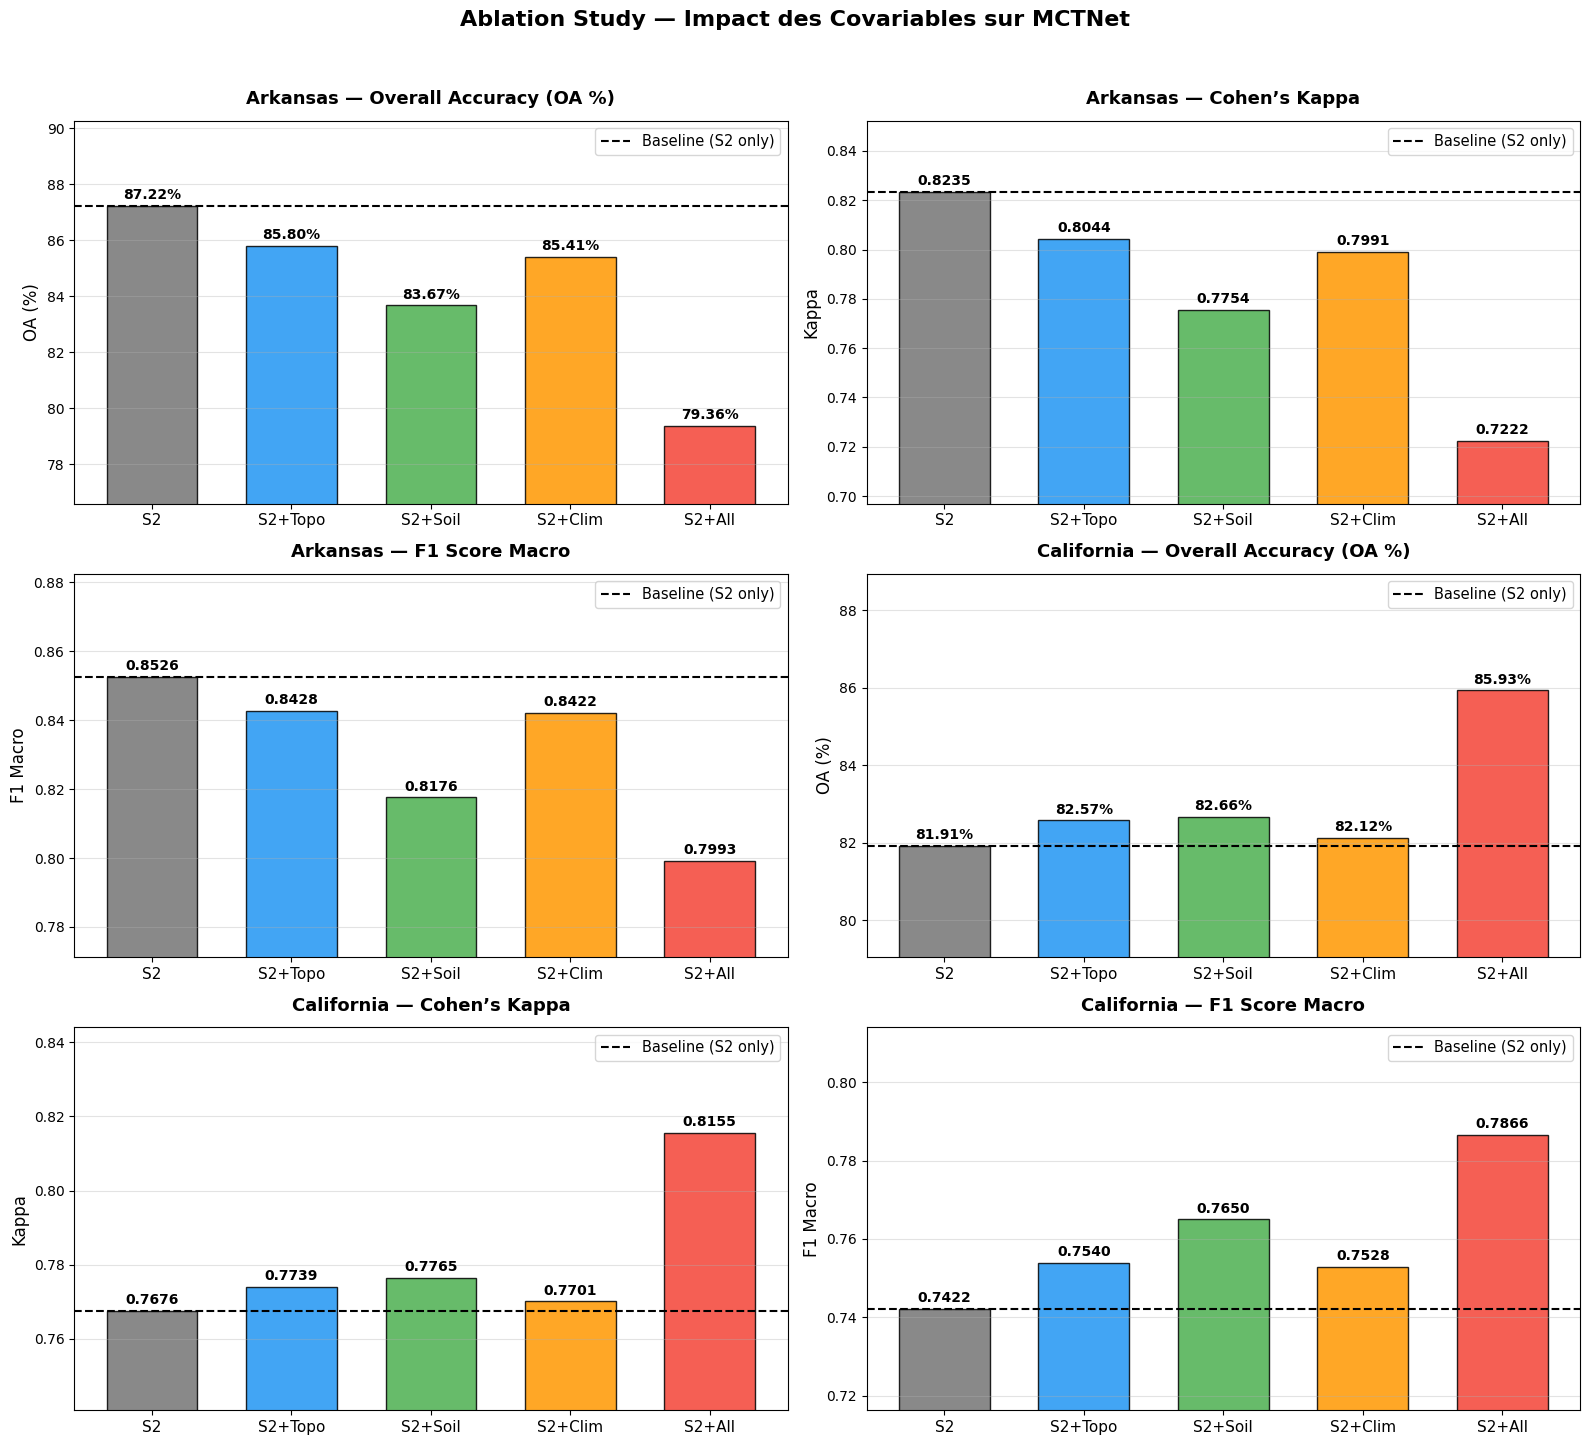

✅ Graphique d'ablation study sauvegardé : ablation_study_resultats.png


In [ ]:


configs_short = ['S2', 'S2+Topo', 'S2+Soil', 'S2+Clim', 'S2+All']
colors = ['#757575', '#2196F3', '#4CAF50', '#FF9800', '#F44336']

oas_ar   = [resultats[cfg]['AR']['OA']   * 100 for cfg in configs_short]
oas_cal  = [resultats[cfg]['CAL']['OA']  * 100 for cfg in configs_short]

kappas_ar  = [resultats[cfg]['AR']['Kappa']  for cfg in configs_short]
kappas_cal = [resultats[cfg]['CAL']['Kappa'] for cfg in configs_short]

f1s_ar   = [resultats[cfg]['AR']['F1']   for cfg in configs_short]
f1s_cal  = [resultats[cfg]['CAL']['F1']  for cfg in configs_short]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Ablation Study — Impact des Covariables sur MCTNet',
             fontsize=16, fontweight='bold', y=0.98)

def plot_bar(ax, vals, title, ylabel, baseline_val, color_list, is_percent=False):
    bars = ax.bar(configs_short, vals, color=color_list,
                  alpha=0.85, edgecolor='black', width=0.65)


    ax.axhline(y=baseline_val, color='black', linestyle='--',
               linewidth=1.5, label='Baseline (S2 only)')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel(ylabel, fontsize=12)


    y_min = min(vals) * 0.965
    y_max = max(vals) * 1.035
    ax.set_ylim([y_min, y_max])


    for bar, val in zip(bars, vals):
        if is_percent:
            text = f'{val:.2f}%'
        else:
            text = f'{val:.4f}'

        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (y_max - y_min) * 0.01,
                text,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.legend(fontsize=10.5)
    ax.grid(axis='y', alpha=0.35)
    ax.tick_params(axis='x', labelsize=11, rotation=0)


plot_bar(axes[0][0], oas_ar,
         'Arkansas — Overall Accuracy (OA %)',
         'OA (%)', oas_ar[0], colors, is_percent=True)

plot_bar(axes[0][1], kappas_ar,
         'Arkansas — Cohen’s Kappa',
         'Kappa', kappas_ar[0], colors)

plot_bar(axes[1][0], f1s_ar,
         'Arkansas — F1 Score Macro',
         'F1 Macro', f1s_ar[0], colors)


plot_bar(axes[1][1], oas_cal,
         'California — Overall Accuracy (OA %)',
         'OA (%)', oas_cal[0], colors, is_percent=True)

plot_bar(axes[2][0], kappas_cal,
         'California — Cohen’s Kappa',
         'Kappa', kappas_cal[0], colors)

plot_bar(axes[2][1], f1s_cal,
         'California — F1 Score Macro',
         'F1 Macro', f1s_cal[0], colors)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig(os.path.join(dossier, 'ablation_study_resultats.png'),
            dpi=220, bbox_inches='tight')
plt.show()

print('✅ Graphique d\'ablation study sauvegardé : ablation_study_resultats.png')